<a href="https://colab.research.google.com/github/ginajsalib/snipersim_framework/blob/main/pythonScripts/correlationAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Starting Power Efficiency Correlation Analysis...
CSV file: fftMergedFullNoLag.csv
PPW column: PPW
Loading data...
Loaded data with 2672 rows and 101 columns
Found 94 numeric columns for correlation analysis
After removing invalid PPW values: 2672 rows

TOP 25 CORRELATIONS WITH POWER EFFICIENCY (PPW)
Rank Metric                                             Pearson  P-val    Spearman P-val    Samples
--------------------------------------------------------------------------------
93   ips^3                                              0.993    0.000    0.993    0.000    2672   
92   ips                                                0.979    0.000    0.993    0.000    2672   
90   total_power                                        0.971    0.000    0.978    0.000    2672   
86   branch_mispred_rate_core0                          0.667    0.000    0.711    0.000    2672   
81   l2_avg_eviction_rate_core1                         0.635    0.000    0.684    0.000    2672   
71   normalized_c

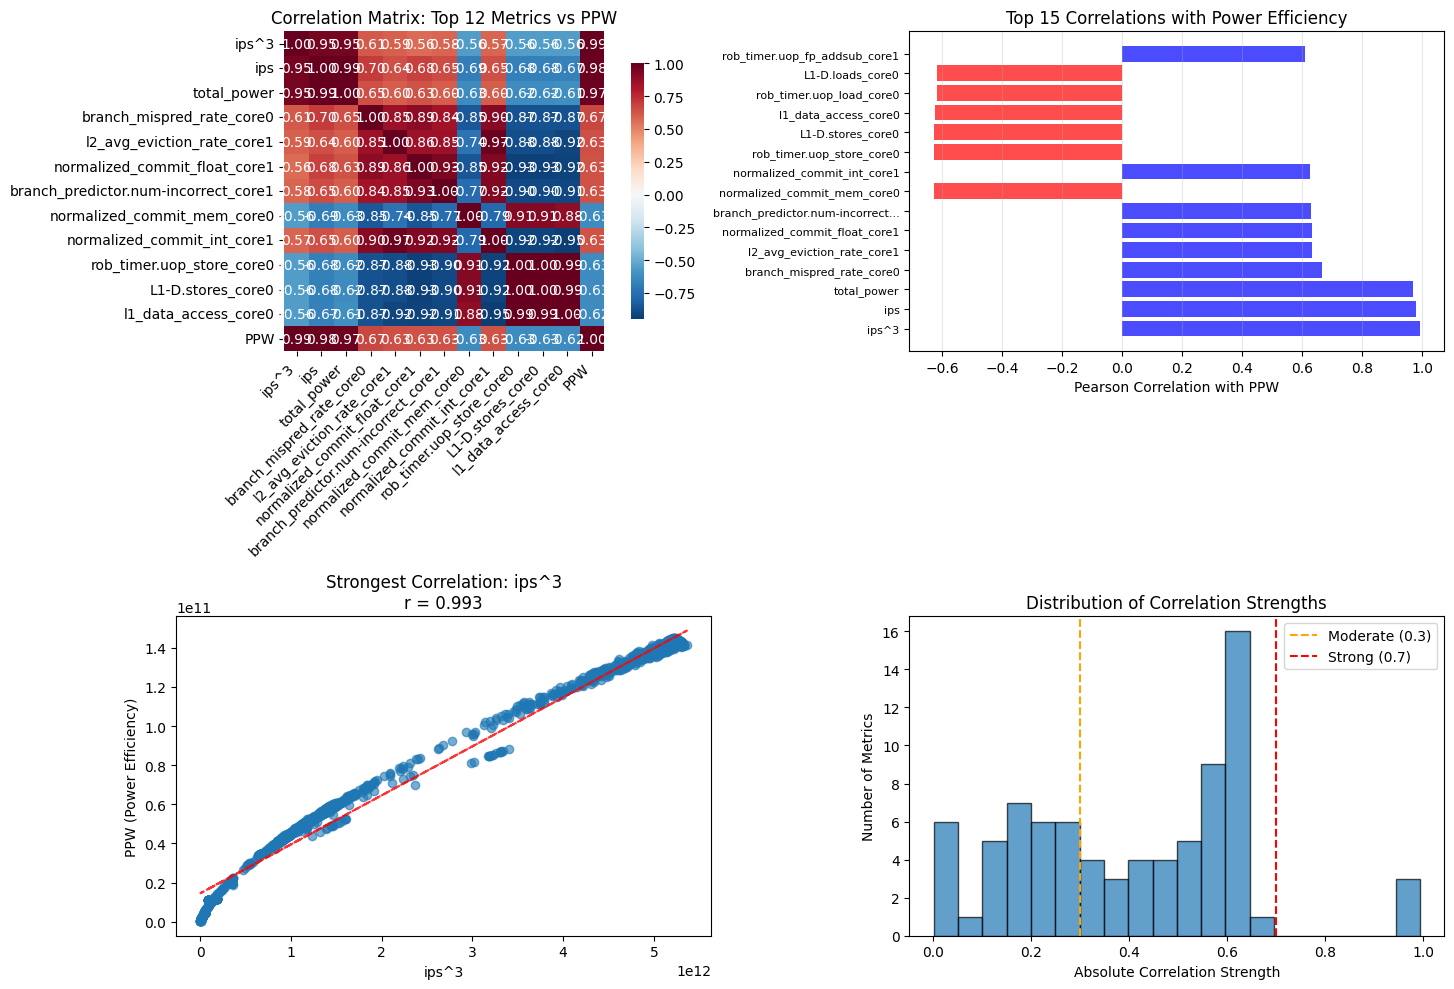


Correlation results saved to: ppw_correlation_results.csv

KEY INSIGHTS:
Strongest POSITIVE correlation: ips^3
  - Correlation: 0.993
  - P-value: 0.000
  - Interpretation: Higher values of this metric tend to INCREASE power efficiency

Strongest NEGATIVE correlation: normalized_commit_mem_core0
  - Correlation: -0.628
  - P-value: 0.000
  - Interpretation: Higher values of this metric tend to DECREASE power efficiency


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

def load_and_analyze_correlations(csv_file_path, ppw_column='PPW'):
    """
    Load CSV data and analyze correlations with power efficiency (PPW)

    Args:
        csv_file_path: Path to your CSV file
        ppw_column: Name of the power efficiency column (default: 'PPW')
    """

    # Load the data
    print("Loading data...")
    df = pd.read_csv(csv_file_path)
    print(f"Loaded data with {len(df)} rows and {len(df.columns)} columns")

    # Check if PPW column exists
    if ppw_column not in df.columns:
        print(f"Error: Column '{ppw_column}' not found in the data.")
        print("Available columns:", df.columns.tolist())
        return None

    # Remove non-numeric columns for correlation analysis
    numeric_columns = df.select_dtypes(include=[np.number]).columns.tolist()

    # Remove directory and period columns if they exist
    exclude_cols = ['directory', 'period']
    numeric_columns = [col for col in numeric_columns if col not in exclude_cols]

    print(f"Found {len(numeric_columns)} numeric columns for correlation analysis")

    # Create a subset with only numeric data
    df_numeric = df[numeric_columns].copy()

    # Remove rows where PPW is NaN or infinite
    df_numeric = df_numeric[np.isfinite(df_numeric[ppw_column])]
    print(f"After removing invalid PPW values: {len(df_numeric)} rows")

    if len(df_numeric) == 0:
        print("No valid data remaining after filtering!")
        return None

    # Calculate correlations with PPW
    correlations = []

    for column in numeric_columns:
        if column == ppw_column:
            continue

        # Remove NaN and infinite values for this column
        valid_mask = np.isfinite(df_numeric[column]) & np.isfinite(df_numeric[ppw_column])
        valid_data = df_numeric[valid_mask]

        if len(valid_data) < 3:  # Need at least 3 points for correlation
            continue

        try:
            # Calculate Pearson correlation
            pearson_corr, pearson_p = pearsonr(valid_data[column], valid_data[ppw_column])

            # Calculate Spearman correlation (rank-based, more robust)
            spearman_corr, spearman_p = spearmanr(valid_data[column], valid_data[ppw_column])

            correlations.append({
                'metric': column,
                'pearson_correlation': pearson_corr,
                'pearson_p_value': pearson_p,
                'spearman_correlation': spearman_corr,
                'spearman_p_value': spearman_p,
                'valid_samples': len(valid_data),
                'abs_pearson': abs(pearson_corr),
                'abs_spearman': abs(spearman_corr)
            })

        except Exception as e:
            print(f"Error calculating correlation for {column}: {e}")

    # Convert to DataFrame and sort by absolute correlation
    corr_df = pd.DataFrame(correlations)

    if len(corr_df) == 0:
        print("No correlations could be calculated!")
        return None

    # Sort by absolute Pearson correlation (descending)
    corr_df = corr_df.sort_values('abs_pearson', ascending=False)

    return df_numeric, corr_df

def print_correlation_summary(corr_df, top_n=20):
    """Print a summary of the top correlations"""

    print(f"\n{'='*80}")
    print(f"TOP {top_n} CORRELATIONS WITH POWER EFFICIENCY (PPW)")
    print(f"{'='*80}")
    print(f"{'Rank':<4} {'Metric':<50} {'Pearson':<8} {'P-val':<8} {'Spearman':<8} {'P-val':<8} {'Samples':<7}")
    print("-" * 80)

    for idx, row in corr_df.head(top_n).iterrows():
        print(f"{idx+1:<4} {row['metric']:<50} "
              f"{row['pearson_correlation']:<8.3f} {row['pearson_p_value']:<8.3f} "
              f"{row['spearman_correlation']:<8.3f} {row['spearman_p_value']:<8.3f} "
              f"{row['valid_samples']:<7}")

    print("\n" + "="*80)

    # Summary by significance
    significant_pearson = corr_df[corr_df['pearson_p_value'] < 0.05]
    significant_spearman = corr_df[corr_df['spearman_p_value'] < 0.05]

    print(f"SIGNIFICANCE SUMMARY:")
    print(f"- Total metrics analyzed: {len(corr_df)}")
    print(f"- Significant Pearson correlations (p < 0.05): {len(significant_pearson)}")
    print(f"- Significant Spearman correlations (p < 0.05): {len(significant_spearman)}")

    # Strong correlations
    strong_corr = corr_df[corr_df['abs_pearson'] > 0.7]
    moderate_corr = corr_df[(corr_df['abs_pearson'] > 0.3) & (corr_df['abs_pearson'] <= 0.7)]

    print(f"- Strong correlations (|r| > 0.7): {len(strong_corr)}")
    print(f"- Moderate correlations (0.3 < |r| <= 0.7): {len(moderate_corr)}")

def create_correlation_plots(df_numeric, corr_df, ppw_column='PPW', top_n=12):
    """Create visualizations for the correlations"""

    # 1. Correlation heatmap for top correlations
    top_metrics = corr_df.head(top_n)['metric'].tolist() + [ppw_column]

    plt.figure(figsize=(15, 10))

    # Create correlation matrix for top metrics
    corr_matrix = df_numeric[top_metrics].corr()

    # Create heatmap
    plt.subplot(2, 2, 1)
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
                square=True, fmt='.2f', cbar_kws={'shrink': 0.8})
    plt.title(f'Correlation Matrix: Top {top_n} Metrics vs PPW')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)

    # 2. Bar plot of correlations
    plt.subplot(2, 2, 2)
    top_15 = corr_df.head(15)
    colors = ['red' if x < 0 else 'blue' for x in top_15['pearson_correlation']]
    plt.barh(range(len(top_15)), top_15['pearson_correlation'], color=colors, alpha=0.7)
    plt.yticks(range(len(top_15)), [m[:30] + '...' if len(m) > 30 else m
                                    for m in top_15['metric']], fontsize=8)
    plt.xlabel('Pearson Correlation with PPW')
    plt.title('Top 15 Correlations with Power Efficiency')
    plt.grid(axis='x', alpha=0.3)

    # 3. Scatter plot of top correlation
    plt.subplot(2, 2, 3)
    top_metric = corr_df.iloc[0]['metric']
    valid_mask = np.isfinite(df_numeric[top_metric]) & np.isfinite(df_numeric[ppw_column])
    valid_data = df_numeric[valid_mask]

    plt.scatter(valid_data[top_metric], valid_data[ppw_column], alpha=0.6)
    plt.xlabel(top_metric)
    plt.ylabel('PPW (Power Efficiency)')
    plt.title(f'Strongest Correlation: {top_metric}\nr = {corr_df.iloc[0]["pearson_correlation"]:.3f}')

    # Add trend line
    z = np.polyfit(valid_data[top_metric], valid_data[ppw_column], 1)
    p = np.poly1d(z)
    plt.plot(valid_data[top_metric], p(valid_data[top_metric]), "r--", alpha=0.8)

    # 4. Distribution of correlation strengths
    plt.subplot(2, 2, 4)
    plt.hist(corr_df['abs_pearson'], bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Absolute Correlation Strength')
    plt.ylabel('Number of Metrics')
    plt.title('Distribution of Correlation Strengths')
    plt.axvline(x=0.3, color='orange', linestyle='--', label='Moderate (0.3)')
    plt.axvline(x=0.7, color='red', linestyle='--', label='Strong (0.7)')
    plt.legend()

    plt.tight_layout()
    plt.show()

def save_correlation_results(corr_df, output_file='correlation_results.csv'):
    """Save correlation results to a CSV file"""
    corr_df.to_csv(output_file, index=False)
    print(f"\nCorrelation results saved to: {output_file}")

def main():
    """Main function to run the correlation analysis"""

    # Update this path to your CSV file
    csv_file_path = 'fftMergedFullNoLag.csv'  # Update this path

    # You can also update the PPW column name if it's different
    ppw_column = 'PPW'  # Update if your column has a different name

    print("Starting Power Efficiency Correlation Analysis...")
    print(f"CSV file: {csv_file_path}")
    print(f"PPW column: {ppw_column}")

    # Load and analyze
    result = load_and_analyze_correlations(csv_file_path, ppw_column)

    if result is None:
        return

    df_numeric, corr_df = result

    # Print summary
    print_correlation_summary(corr_df, top_n=25)

    # Create visualizations
    print("\nCreating correlation visualizations...")
    create_correlation_plots(df_numeric, corr_df, ppw_column, top_n=12)

    # Save results
    save_correlation_results(corr_df, 'ppw_correlation_results.csv')

    # Print some additional insights
    print(f"\n{'='*80}")
    print("KEY INSIGHTS:")
    print(f"{'='*80}")

    strongest_pos = corr_df[corr_df['pearson_correlation'] > 0].iloc[0] if len(corr_df[corr_df['pearson_correlation'] > 0]) > 0 else None
    strongest_neg = corr_df[corr_df['pearson_correlation'] < 0].iloc[0] if len(corr_df[corr_df['pearson_correlation'] < 0]) > 0 else None

    if strongest_pos is not None:
        print(f"Strongest POSITIVE correlation: {strongest_pos['metric']}")
        print(f"  - Correlation: {strongest_pos['pearson_correlation']:.3f}")
        print(f"  - P-value: {strongest_pos['pearson_p_value']:.3f}")
        print(f"  - Interpretation: Higher values of this metric tend to INCREASE power efficiency")

    if strongest_neg is not None:
        print(f"\nStrongest NEGATIVE correlation: {strongest_neg['metric']}")
        print(f"  - Correlation: {strongest_neg['pearson_correlation']:.3f}")
        print(f"  - P-value: {strongest_neg['pearson_p_value']:.3f}")
        print(f"  - Interpretation: Higher values of this metric tend to DECREASE power efficiency")

if __name__ == "__main__":
    main()